## Alaska GHCND AFI Extreme-Value Analysis with Generalized Extreme Value Modeling

This notebook fits Generalized Extreme Value (GEV) distributions to the Air-Freezing Index (AFI) time series from Alaskan GHCND stations. The analysis includes location and scale parameter variations with climate covariates, cross-validation for model assessment, and bootstrap confidence intervals for derived quantities (return levels and parameter changes).

In [412]:
itest='Alaska_GHCND_ij_glostLocSca_extremes_gev_CV_CI300'

### Configuration and Environment Setup

Set up test name identifier and configure parallel processing threads for numerical computation.

In [413]:
import os

# Set OMP_NUM_THREADS to 4
os.environ["OMP_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"
os.environ["OPENBLAS_NUM_THREADS"]="8"

In [414]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy
import cftime
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as colors
import cmaps
from xhistogram.xarray import histogram
from statsmodels.nonparametric.smoothers_lowess import lowess as  sm_lowess
from copy import copy
import geopandas as gpd
from shapely.geometry import Point

In [415]:
import datetime
from matplotlib import cm

In [416]:
import rpy2
from rpy2.robjects.packages import importr, data
from rpy2.robjects import pandas2ri
import rpy2.robjects as ro
from rpy2.robjects import globalenv


%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [417]:
%R Sys.setenv(OMP_NUM_THREADS = 8)
%R Sys.setenv(OPENBLAS_NUM_THREADS = 8)
%R Sys.setenv(MKL_NUM_THREADS = 8)

1


In [418]:
extRemes = importr("extRemes")
twosamples = importr("twosamples")
dplyr = importr("dplyr")
%R source("R_utils.R")

In [419]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

In [420]:
import warnings
warnings.filterwarnings('ignore')
%R options( warn = -1 )

### R Integration and Extreme-Value Functions

Define custom R functions for bootstrapped estimation and cross-validation of GEV parameters. The `extremes_bootLS` function generates confidence intervals by resampling time series with replacement, while `cross_validation` partitions data and evaluates model performance on held-out folds.

In [421]:
%%R -w 800 --type=cairo
 extremes_bootLS <- function(r_df,fevd_options,n,alpha,rp){

  ntime <- length(r_df[['AFI']])

  boot_RL <- array(NA, dim = c(ntime, length(rp),n))
  boot_Loc <- matrix(data = NA,nrow=ntime,ncol=n)
  boot_Scale <- matrix(data = NA,nrow=ntime,ncol=n)

  boot_LocDiff <- matrix(nrow=1,ncol=n)
  boot_ScaleDiff <- matrix(nrow=1,ncol=n)
  boot_RLDiff <- matrix(nrow=length(rp),ncol=n)
  RiskRatios <- matrix(nrow=length(rp),ncol=n)

  i<-1
  while (i < n){
      index <- 1:ntime
      bx <- sample(index, size = ntime, replace = TRUE)
      r_df['bglost']<- r_df[['glost']][bx]
      r_df['bAFI']<- r_df[['AFI']][bx]
      r_df['btime'] <- r_df[['time']][bx]
      initial_vals <- list(location = mean(r_df$bAFI), scale = sd(r_df$bAFI), shape = 0.1)
      call_fevd <- paste("fevd(bAFI, data = r_df,",gsub("glost", "bglost", fevd_options),")")
      fit <- eval(parse(text = call_fevd))            
      if (length(which(findpars(fit)$scale<=0))==0){
          boot_rl <- return.level(fit, return.period = rp)
          boot_Loc[,i] <- findpars(fit)$location[order(r_df$btime)]
          boot_Scale[,i] <- findpars(fit)$scale[order(r_df$btime)]
          boot_RL[,,i] <- boot_rl[order(r_df$btime),]
          boot_LocDiff[i] <- boot_Loc[ntime,i] - boot_Loc[1,i]
          boot_ScaleDiff[i] <- boot_Scale[ntime,i] - boot_Scale[1,i]
          boot_RLDiff[,i] <- boot_RL[ntime,,i] - boot_RL[1,,i]

          i <- i+1
      }     
      }     
  Diffloc_q <- apply(boot_LocDiff, 1, quantile, probs = c(alpha/2, 0.5, 1-alpha/2), na.rm = TRUE)
  Diffsca_q <- apply(boot_ScaleDiff, 1, quantile, probs = c(alpha/2, 0.5, 1-alpha/2), na.rm = TRUE)
  DiffRL_q <- t(apply(boot_RLDiff, 1, quantile, probs = c(alpha/2, 0.5, 1-alpha/2), na.rm = TRUE))
  loc_q <- t(apply(boot_Loc, 1, quantile, probs = c(alpha/2, 0.5, 1-alpha/2), na.rm = TRUE))
  sca_q <- t(apply(boot_Scale, 1, quantile, probs = c(alpha/2, 0.5, 1-alpha/2), na.rm = TRUE))
  RL_q <- apply(boot_RL, c(1,2), quantile, probs = c(alpha/2, 0.5, 1-alpha/2), na.rm = TRUE)

  return(list(Dloc_q=Diffloc_q,Dsca_q=Diffsca_q,DRL_q=DiffRL_q,loc_q=loc_q,sca_q=sca_q,RL_q=RL_q))
  }
##########################  

In [422]:
%%R -w 800 --type=cairo
#===============================================================================
#===============================================================================
#===============================================================================
# function to define indices of rows of dataframe that assign observations to splits
# This function was written by Finn Lindgren
# ARGS:
# N: positive integer; (= number of rows of full dataframe)
# K: positive integer; (= number of splits for cross-validation)
# Value/Output: numeric of length N with indices 1,...,K defining random splitting into K subsets
cv_indices_splits <- function(N, K=K){
  split_sizes <-  ceiling((1:K)*N/K) - ceiling((0:(K-1))*N/K)
  sample(rep(1:K, times=split_sizes), size=N, replace=FALSE)
}
#===============================================================================
# function that takes data frame and splits/partitions in to training and test dataframes
# This function was written by Finn Lindgren
# ARGS:
# data: a data frame
# splits: index vector defining the K data splits (as produced by cv_indices_splits)
# k: the index k \in 1:K for the subset to be used as test/validation set
# Value/Output:
# a list with two named elements;
# 1.) Train: training data frame with rows of data in subsets with split index not equal to k
# 2.) Test: test data frame with rows of data in subsets with split index equal to k
cv_split <- function(data, splits, k){
  list(Train =  data[((splits != k)&((splits != 0))),  ,drop=FALSE],
       Test  =  data[splits == k,  ,drop=FALSE][1:length(which(splits==k))-1,])

}
cv_split_modulo <- function(data, K, ik){
  list(Train =  data[c(as.integer(K*(ik-1)+1):as.integer(K*(ik-1)+floor(K/2)),as.integer(K*(ik-1)+1+floor(K/2+1)):as.integer(K*ik)),] ,
       Test  =  data[as.integer(K*(ik-1)+floor(K/2+1)),])
}

In [423]:
%%R -w 800 --type=cairo

cross_validation <- function(data,fevd_options,K){

#===============================================================================
# function that calls Mod_Train_Test for all for each of the K splits and collects the results
# ARGS:
# data: full data frame to be split in in to training/test sets
# splits: the splitting indices (as produced by cv_indices_splits)
# formula_list: a list of formulas as required by evgam

  AIC_cv <- NULL
  BIC_cv <- NULL
  scores <- list()  # note AIC/BIC need dealt with
  tests <- list()
  for(k in 1:K){
    data_k <- cv_split(data=data, splits=splits, k)
    initial_vals <- list(location = mean(data_k$Train[['AFI']]), scale = sd(data_k$Train[['AFI']]), shape = 0.1)
    call_fevd <- paste("fevd(AFI, data = data_k$Train,",fevd_options,")")
    mod <- eval(parse(text = call_fevd))
    pp <- summary(mod, silent = TRUE)
    if (length(pp$par)==3){
        location <- rep(pp$par[['location']],times =length(data_k$Test$time))
        scale <- rep(pp$par[['scale']],times =length(data_k$Test$time))
        shape <- rep(pp$par[['shape']],times =length(data_k$Test$time))
    } else if ((length(pp$par)==4)){
        location <- pp$par[['mu0']]+pp$par[['mu1']]*data_k$Test$glost
        scale <- rep(pp$par[['scale']],times =length(data_k$Test$time))
        shape <- rep(pp$par[['shape']],times =length(data_k$Test$time))
    } else if ((length(pp$par)==5)){
        location <- pp$par[['mu0']]+pp$par[['mu1']]*data_k$Test$glost
        scale <- pp$par[['sigma0']]+pp$par[['sigma1']]*data_k$Test$glost
        shape <- rep(pp$par[['shape']],times =length(data_k$Test$time))
    }
    params <-list(location=location,scale=scale,shape=shape)
    params['cell'] <- 1
    TrainAndTest <- list(mod.scores=GEV_scores(data_k$Test,params), mod.AIC=pp$AIC, mod.BIC=pp$BIC)

    scores[[k]] <- cbind(TrainAndTest[[1]], time=data_k$Test$time,split_k = k)
    AIC_cv[k] <- TrainAndTest[[2]]
    BIC_cv[k] <- TrainAndTest[[3]]
    tests[[k]] <- cbind(KS_CVM(data_k$Test,params), time=data_k$Test$time, split_k = k)
  }
  scores <- do.call(rbind, scores)
  tests <- do.call(rbind, tests)
  list(scores_cv=scores, tests_cv=tests, AIC_cv=AIC_cv, BIC_cv=BIC_cv)
}

In [424]:
def find_nearest_valid(arr, lon, lat, radius=1):
    """Find the nearest valid value in a dataset for a given variable and coordinates."""
    # Select a subset of points within a certain radius
    subset = arr.sel(lon=slice(lon-radius, lon+radius), lat=slice(lat-radius, lat+radius))
    # Calculate the Euclidean distance to the points in the subset
    dist = np.sqrt((subset.lon - lon)**2 + (subset.lat - lat)**2)
    # Create a new dataset that only includes valid values
    valid_subset = subset.where(~np.isnan(subset), drop=True)
    # Find the coordinates of the valid point with the smallest distance
    min_dist_coords = dist.where(dist == dist.where(~np.isnan(valid_subset)).min(), drop=True)
    nearest_lon = min_dist_coords.lon.values.item()
    nearest_lat = min_dist_coords.lat.values.item()
    # Select the nearest valid value
    nearest = valid_subset.sel(lon=nearest_lon, lat=nearest_lat)
    return nearest.to_dataframe().reset_index()
    arr_series = arr.sel(lon=lon, lat=lat,method="nearest").to_dataframe().reset_index()

### Data Loading

Load Air-Freezing Index (AFI) from GHCND stations, ERA5-derived AFI for spatial comparison, GLOST climate covariates, and geographic data defining the Alaska analysis domain.

In [425]:

ifile='~/data/AFI/GHCND_AFI_utils_AK.nc'
ds = xr.open_dataset(ifile)
afi = ds['AFI']
name = ds['name']
elevation = ds['elevation']
longitude = ds['longitude']
latitude = ds['latitude']
units='°C-days'

In [426]:
lon_min = 185
lon_max = 232
lat_min = 50
lat_max = 72

yearb=1979
yeare=2025

ifile=f'~/data/AFI/Alaska_ij_glostLocSca_extremes_gev_CV_1979_2025.nc'
dse = xr.open_dataset(ifile)
dse = dse.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))
dse['lon'] = dse['lon']-360
locationERA5 = dse['location']
scaleERA5 = dse['scale']
shapeERA5 = dse['shape']

valid_locationERA5 = locationERA5.mean('time').where(locationERA5.mean('time').notnull(), drop=True)
valid_scaleERA5 = scaleERA5.mean('time').where(scaleERA5.mean('time').notnull(), drop=True)
valid_shapeERA5 = shapeERA5.mean('time').where(shapeERA5.mean('time').notnull(), drop=True)

In [427]:

ifile='~/data/AFI/ERA5_AFI_1941_2025.nc'
dsae = xr.open_dataset(ifile)
dsae = dsae.sel(time=slice(f'{yearb}-01-01',f'{yeare}-10-01'))
dsae = dsae.sortby('lat')
dsae = dsae.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))
dsae['lon'] = dsae['lon']-360
dsae['time'] = np.arange(yearb,yeare+1,1)

units = 'degree-days (°C)'

In [428]:
fileGLOST = '~/data/AFI/annual_LOESS_NOAA_GLOST_anomaly_1850_2025.nc'
ds_glost = xr.open_dataset(fileGLOST)
ann_glost = ds_glost['GLOST']


In [429]:
ds = ds.merge({'glost':ann_glost.sel(time=ds.time)}) 
ds = ds.sel(time=slice(yearb,yeare))  

### Analysis Parameters and Output Array Initialization

Define return periods, quantiles, cross-validation splits, and random seed. Initialize xarray output arrays to store GEV parameters (location, scale, shape), return levels, goodness-of-fit metrics (AIC/BIC), p-values for nested model tests, cross-validation scores, and bootstrap confidence intervals.

In [430]:
return_periods = [2, 5, 10, 20, 50, 100]
%R rp <- c(2, 5, 10, 20, 50, 100)
Tquantile = [0.05,0.5,0.95]
K = 5 # number of splits for Cross-Validation
%R -i K 


In [431]:
%R set.seed(1)

In [432]:
# Define arrays GEV output
location = xr.zeros_like(ds['AFI'])*np.nan
shape = xr.zeros_like(ds['AFI'])*np.nan
scale = xr.zeros_like(ds['AFI'])*np.nan
rl = xr.zeros_like(ds['AFI']).expand_dims(dim={'return_periods':return_periods})*np.nan
AIC = xr.zeros_like(ds['AFI'].mean('time'))*np.nan
BIC = xr.zeros_like(ds['AFI'].mean('time'))*np.nan
pvalueL = xr.zeros_like(ds['AFI'].mean('time'))*np.nan
pvalueS = xr.zeros_like(ds['AFI'].mean('time'))*np.nan

# Define arrays Confidence Interval 
location_q = xr.zeros_like(ds['AFI']).expand_dims(quantile=Tquantile)*np.nan
scale_q = xr.zeros_like(ds['AFI']).expand_dims(quantile=Tquantile)*np.nan
rl_q = xr.zeros_like(ds['AFI']).expand_dims(quantile=Tquantile).expand_dims(dim={'return_periods':return_periods})*np.nan
Dlocation_q = xr.zeros_like(ds['AFI'].mean('time')).expand_dims(quantile=Tquantile)*np.nan
Dscale_q = xr.zeros_like(ds['AFI'].mean('time')).expand_dims(quantile=Tquantile)*np.nan
Drl_q = xr.zeros_like(ds['AFI'].mean('time')).expand_dims(quantile=Tquantile).expand_dims(dim={'return_periods':return_periods})*np.nan

# Define arrays Cross-Validation
SE_cv = xr.zeros_like(ds['AFI'])*np.nan
DawSeb_cv = xr.zeros_like(ds['AFI'])*np.nan
CRPS_cv = xr.zeros_like(ds['AFI'])*np.nan
WCRPS_cv = xr.zeros_like(ds['AFI'])*np.nan
KS_D_cv = xr.zeros_like(ds['AFI'])*np.nan
KS_pvalue_cv = xr.zeros_like(ds['AFI'])*np.nan
CVM_D_cv = xr.zeros_like(ds['AFI'])*np.nan
CVM_pvalue_cv = xr.zeros_like(ds['AFI'])*np.nan
AIC_cv = xr.zeros_like(ds['AFI'].mean('time')).expand_dims(split=K)*np.nan
BIC_cv = xr.zeros_like(ds['AFI'].mean('time')).expand_dims(split=K)*np.nan

### Station Selection

Select stations with at least 70% data coverage over the analysis period.

In [433]:
xxx = xr.where(np.isnan(ds['AFI'].sel(time=slice(yearb,yeare+1)))==False,1,0)
Tstations = np.where(xxx.sum('time')>=(yeare+1-yearb)*70/100.)[0]
Tstations = ds['station'].isel(station=Tstations).data

In [434]:
Tstations

array(['USC00503672', 'USC00505604', 'USC00505136', 'USW00026412',
       'USC00509641', 'USC00503299', 'USC00500464', 'USC00500243',
       'USC00507570', 'USC00507738', 'USC00502607', 'USC00506581',
       'USW00026529', 'USC00505733', 'USC00502587', 'USC00505464',
       'USC00505778', 'USC00502107'], dtype='<U11')

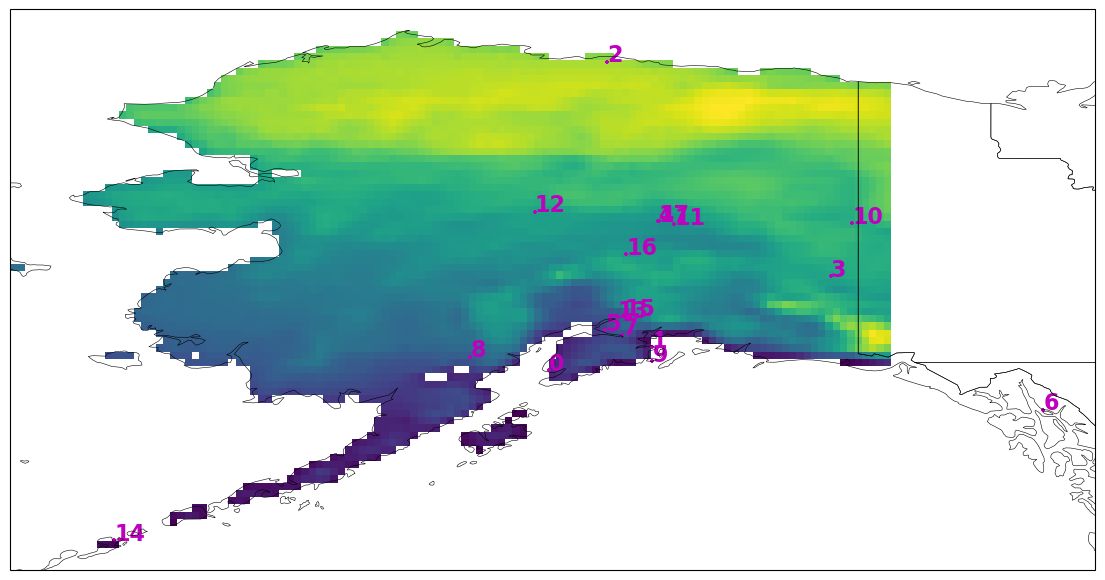

In [435]:
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(14,12),subplot_kw={'projection':ccrs.PlateCarree()})
colors=cm.get_cmap('turbo',len(Tstations))
fig.subplots_adjust(hspace=1.15)
locationERA5.mean('time').plot(ax=ax,add_colorbar=False)
ax.add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
for ij in range(0,len(Tstations)):
  ilon = longitude.sel(station =Tstations[ij]).data
  ilat = latitude.sel(station =Tstations[ij]).data
  istation = Tstations[ij]
  ax.scatter(ilon,ilat,marker='+',s=10,color='m')
  ax.text(ilon,ilat,ij,color='m',fontsize=16,fontweight='bold')

plt.show()

**Figure caption.** Map of selected GHCND stations (marked with magenta plus signs) overlaid on the mean location parameter from ERA5-derived GEV fits. Station indices are labeled to identify each location in the analysis domain.

### Model Specification

Define the fevd (Fit an Extreme Value Distribution) formula with linear location and scale parameters as functions of GLOST climate covariate. 

In [436]:
%R fevd_options <- "type='GEV', method='MLE', initial = initial_vals, location.fun = ~ glost, scale.fun = ~ glost"

array(["type='GEV', method='MLE', initial = initial_vals, location.fun = ~ glost, scale.fun = ~ glost"],
      dtype='<U93')

In [ ]:
compute_CI = True # Turn on Confidence Interval computation

In [438]:
print(datetime.datetime.now())

2026-08-19 15:35:10.593544


### Main Processing Loop: Station-by-Station GEV Fitting

For each selected GHCND station, extract the AFI time series, compare with ERA5 nearest-neighbor values, fit GEV distributions with GLOST covariate, perform 5-fold cross-validation for model diagnostics, compute bootstrap confidence intervals (optional), and populate the output arrays with estimates and uncertainty measures.

#########################################
Processing station HOMER 8 NW, AK US at lon=-151.6347, lat=59.7444
#########################################


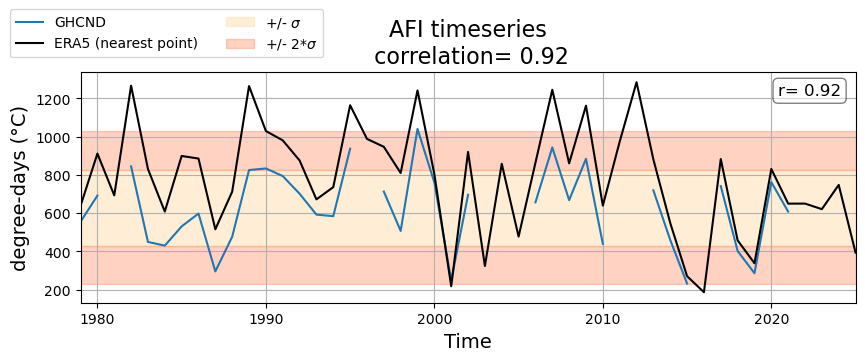

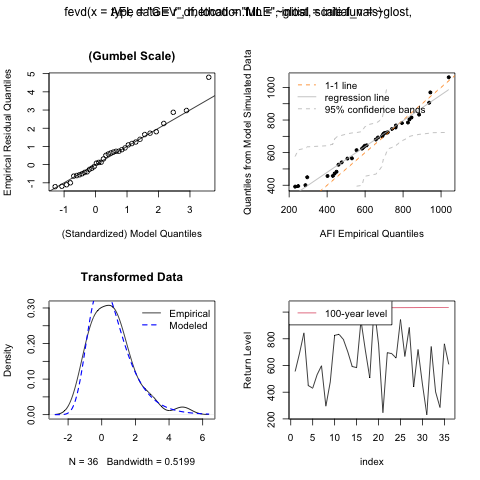

#########################################
Processing station MAIN BAY, AK US at lon=-148.0931, lat=60.5181
#########################################


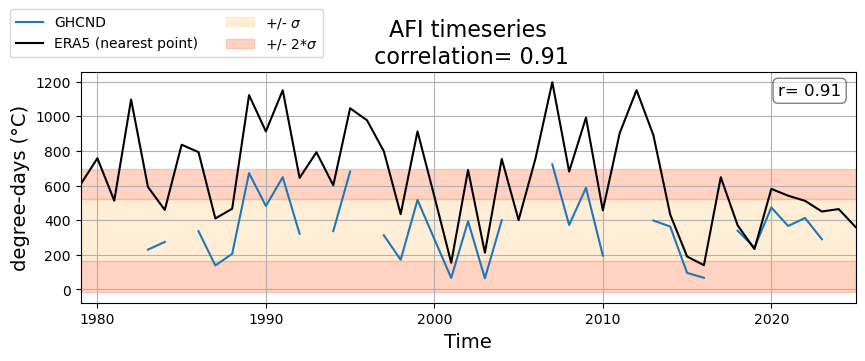

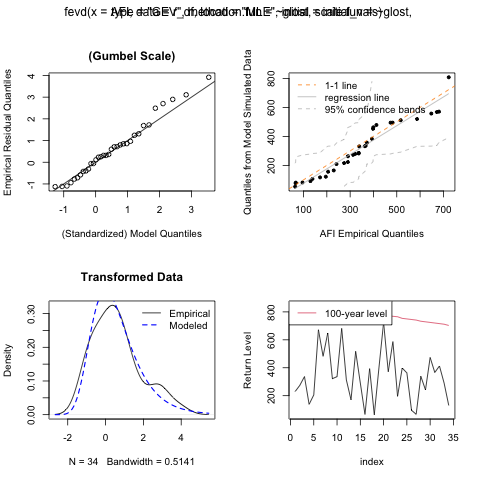

#########################################
Processing station KUPARUK, AK US at lon=-149.6114, lat=70.3289
#########################################


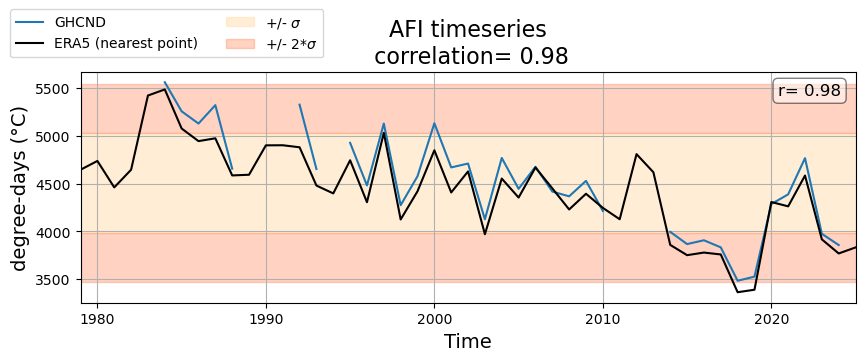

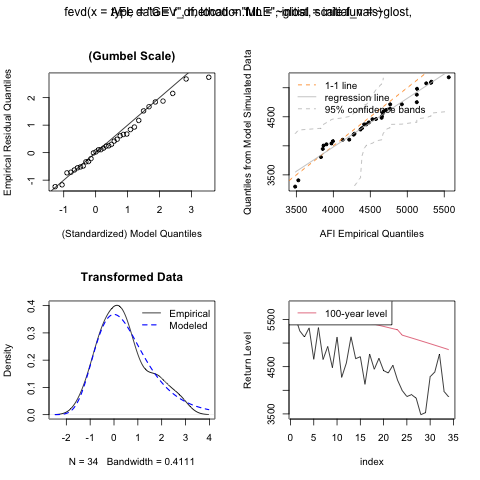

#########################################
Processing station NORTHWAY AIRPORT, AK US at lon=-141.93834, lat=62.96148
#########################################


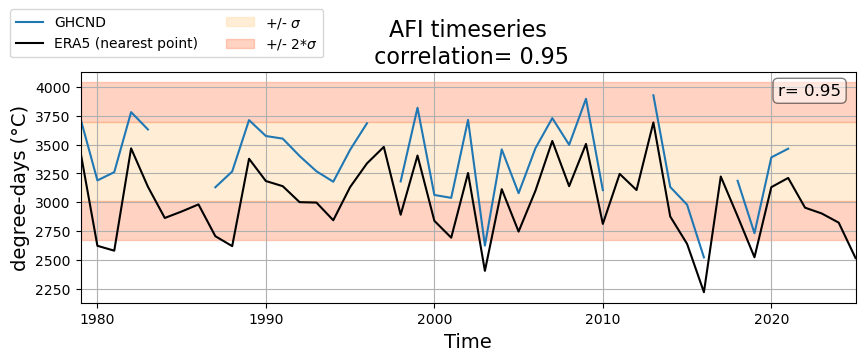

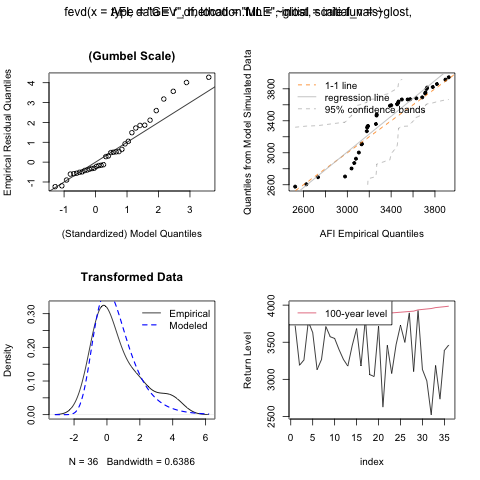

#########################################
Processing station UNIVERSITY EXPERIMENTAL STATION, AK US at lon=-147.861, lat=64.8569
#########################################


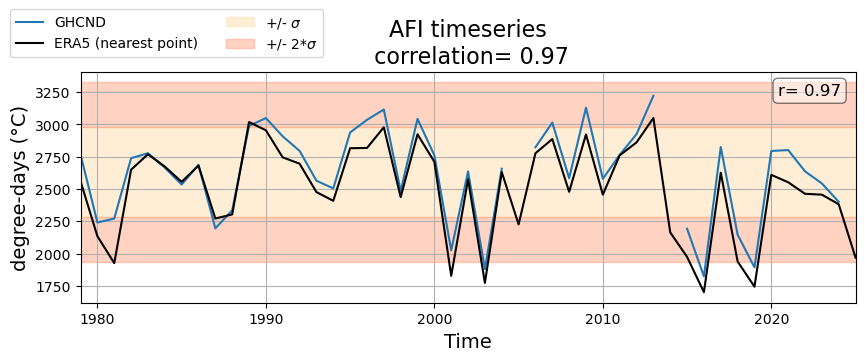

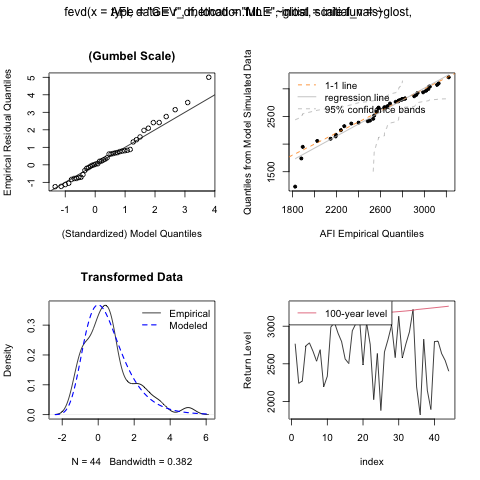

#########################################
Processing station GLEN ALPS, AK US at lon=-149.6936, lat=61.1
#########################################


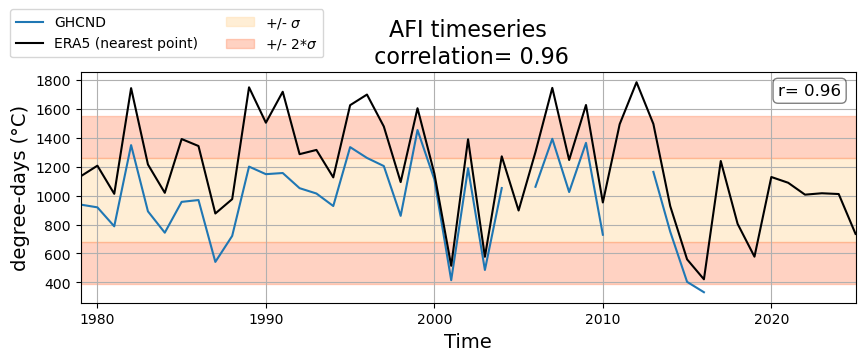

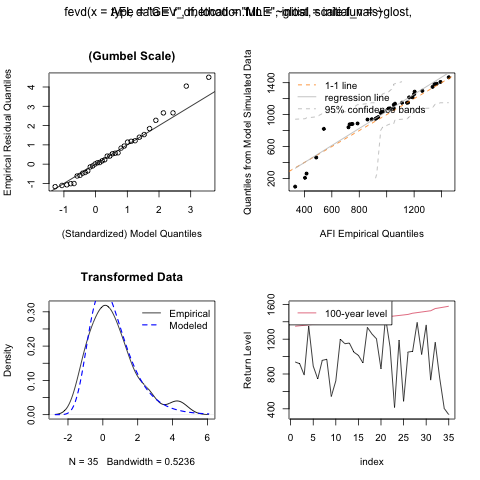

#########################################
Processing station AUKE BAY, AK US at lon=-134.645, lat=58.3814
#########################################


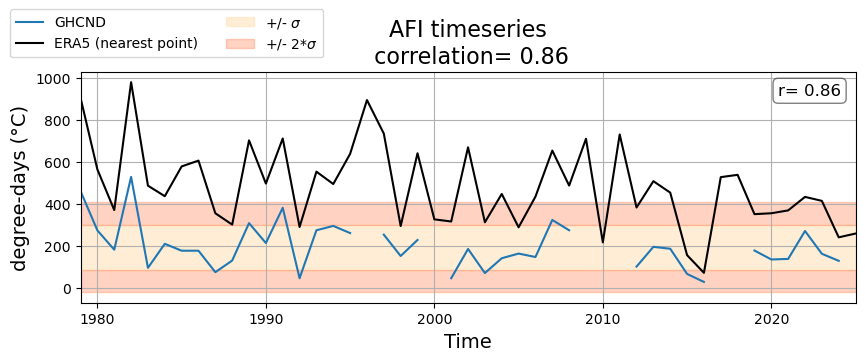

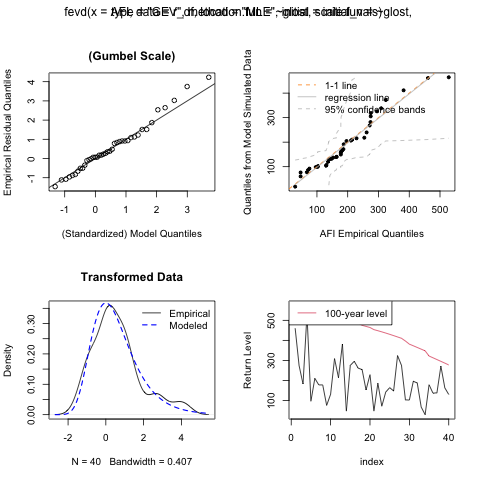

#########################################
Processing station ALYESKA, AK US at lon=-149.1108, lat=60.9583
#########################################


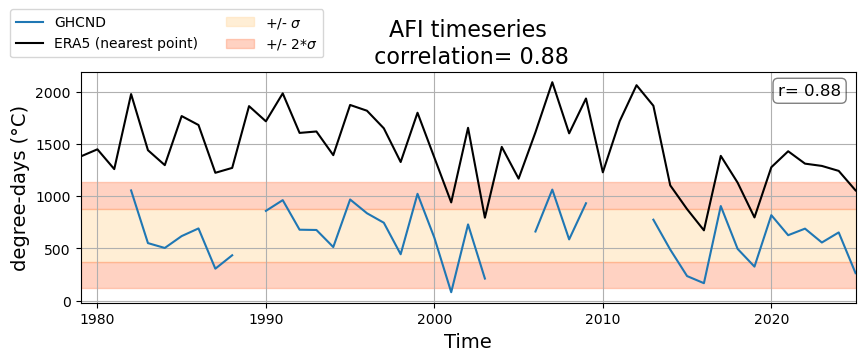

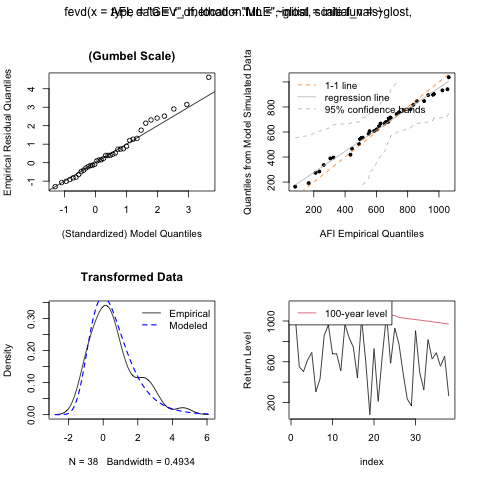

#########################################
Processing station PORT ALSWORTH, AK US at lon=-154.3163, lat=60.2036
#########################################


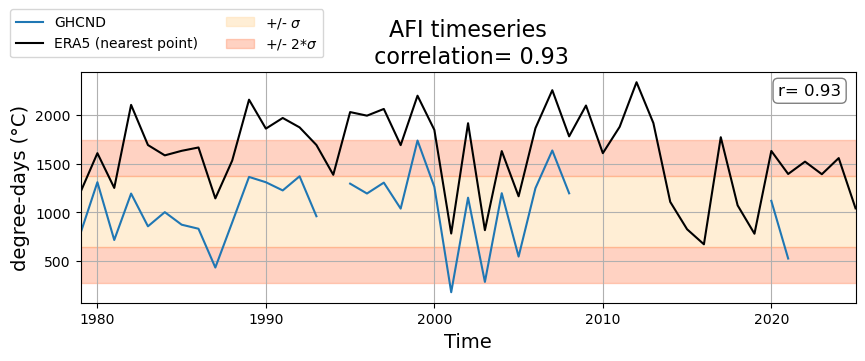

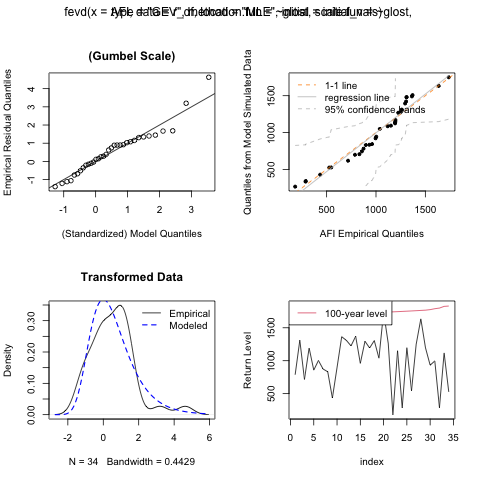

#########################################
Processing station PORT SAN JUAN, AK US at lon=-148.0672, lat=60.0502
#########################################


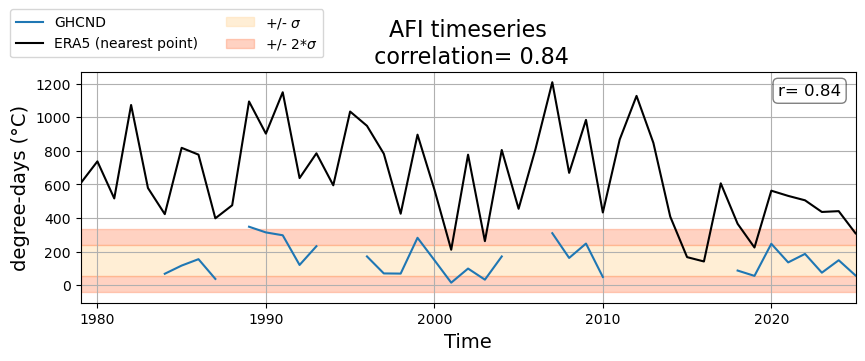

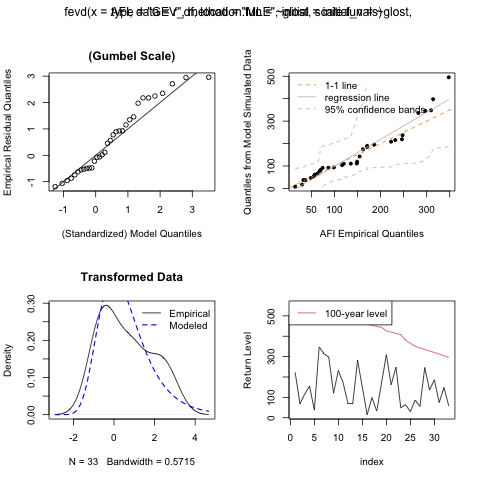

#########################################
Processing station EAGLE, AK US at lon=-141.2036, lat=64.7856
#########################################


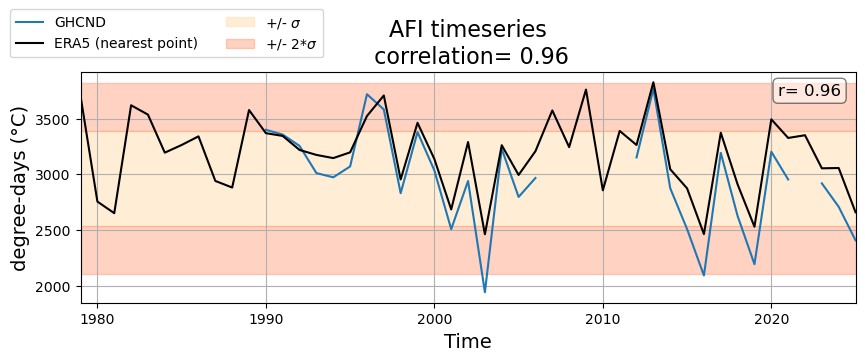

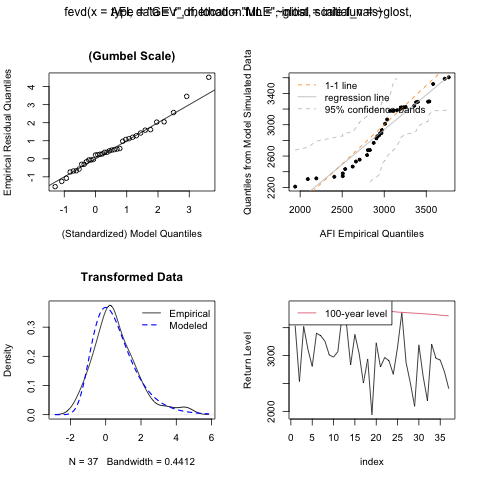

#########################################
Processing station NORTH POLE, AK US at lon=-147.3253, lat=64.7581
#########################################


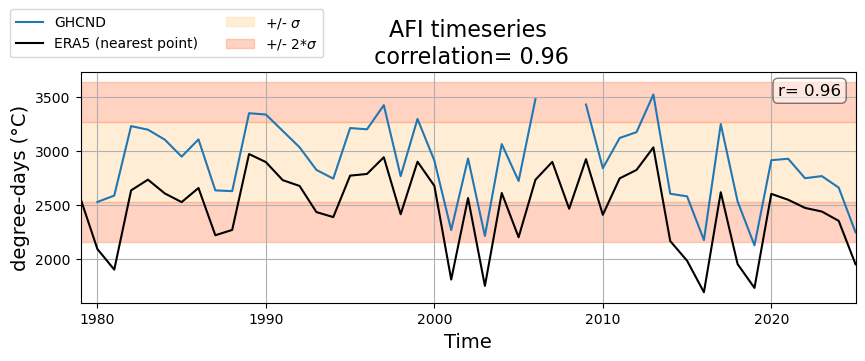

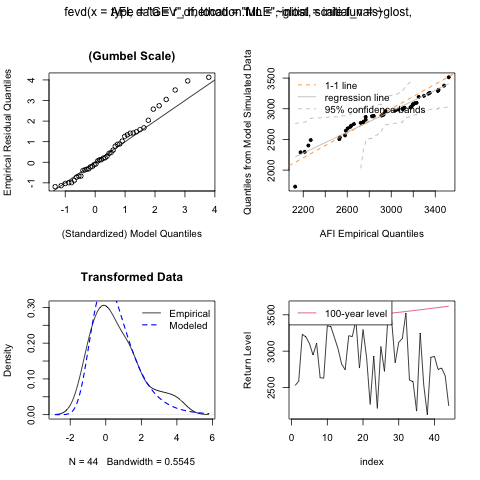

#########################################
Processing station TANANA AIRPORT, AK US at lon=-152.10676, lat=65.173
#########################################


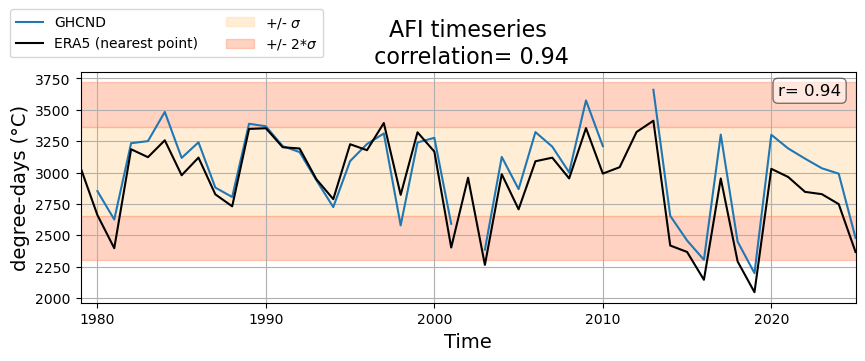

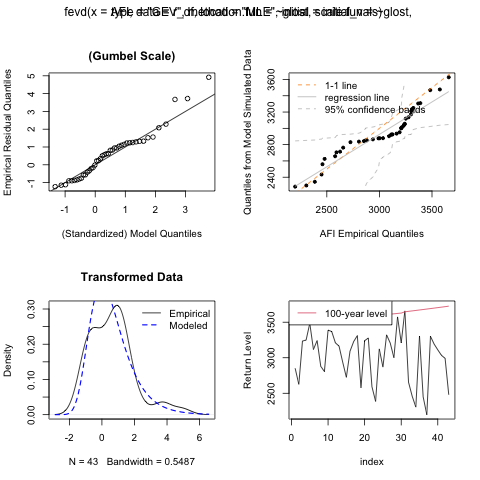

#########################################
Processing station MATANUSKA EXPERIMENTAL FARM, AK US at lon=-149.2541, lat=61.5663
#########################################


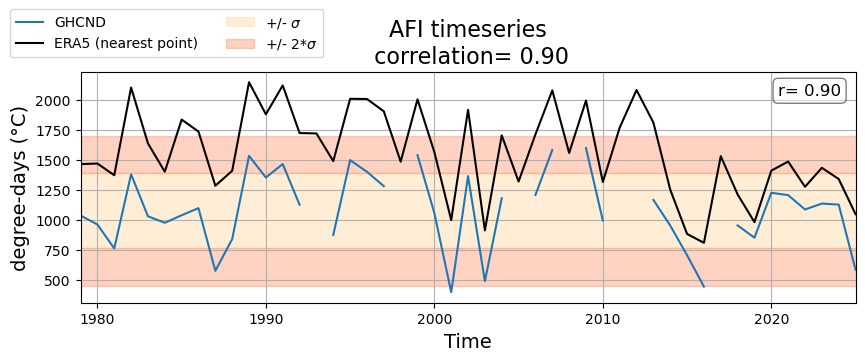

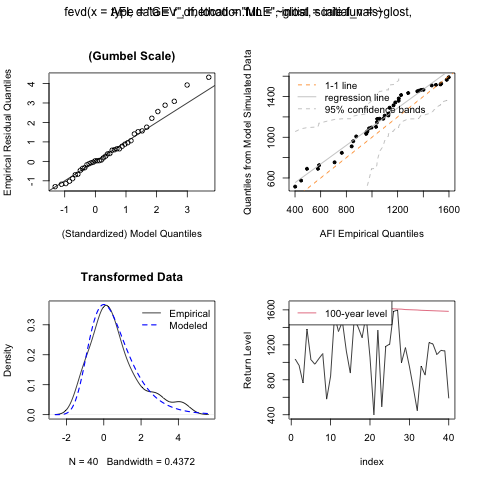

#########################################
Processing station DUTCH HARBOR, AK US at lon=-166.5433, lat=53.895
#########################################


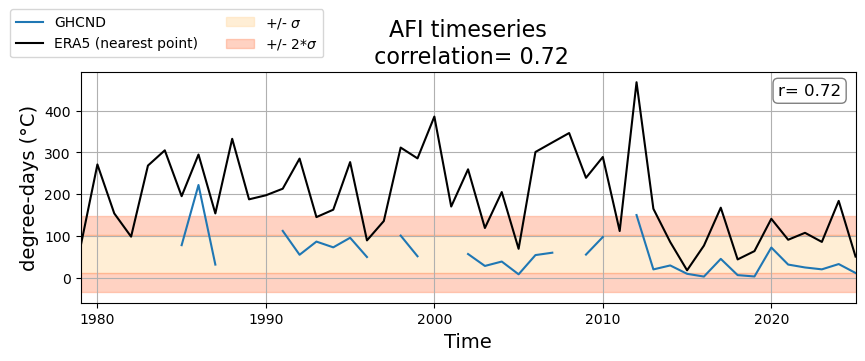

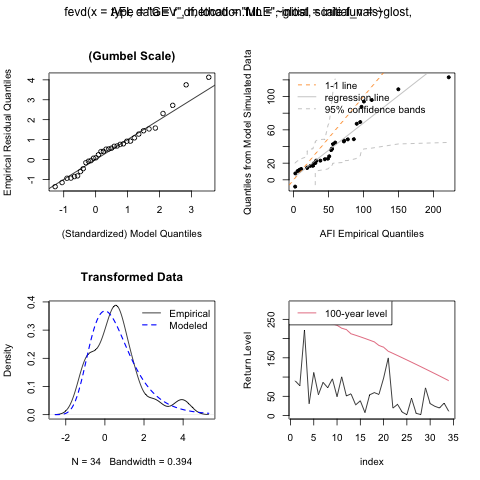

#########################################
Processing station LAZY MOUNTAIN, AK US at lon=-149.0365, lat=61.6266
#########################################


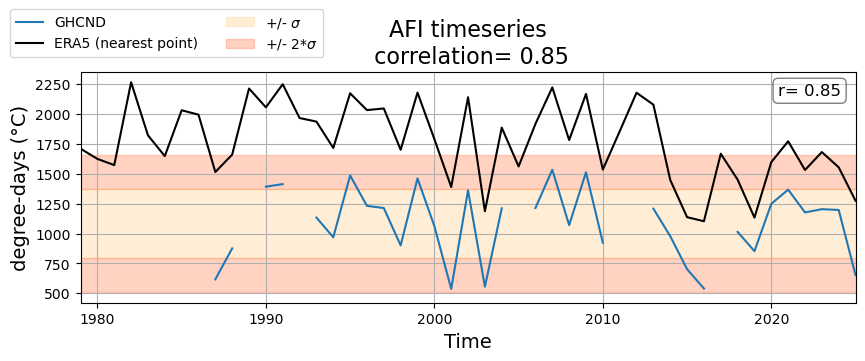

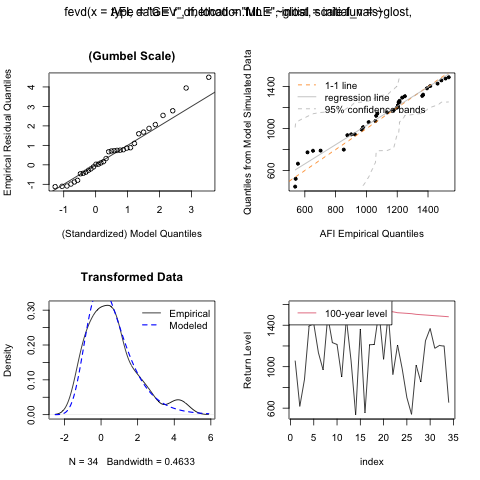

#########################################
Processing station MCKINLEY PARK, AK US at lon=-148.9692, lat=63.7175
#########################################


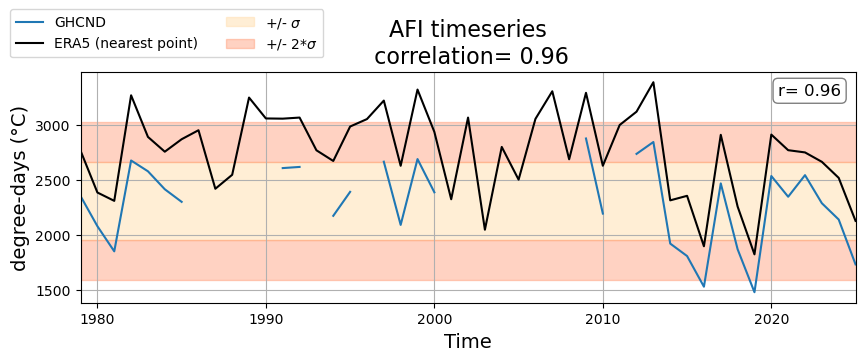

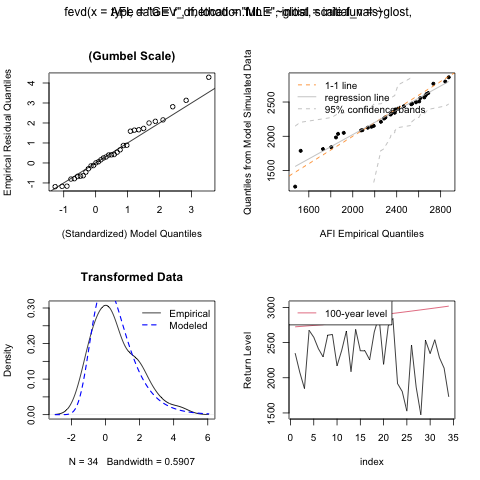

#########################################
Processing station COLLEGE OBSERVATORY, AK US at lon=-147.8484, lat=64.8603
#########################################


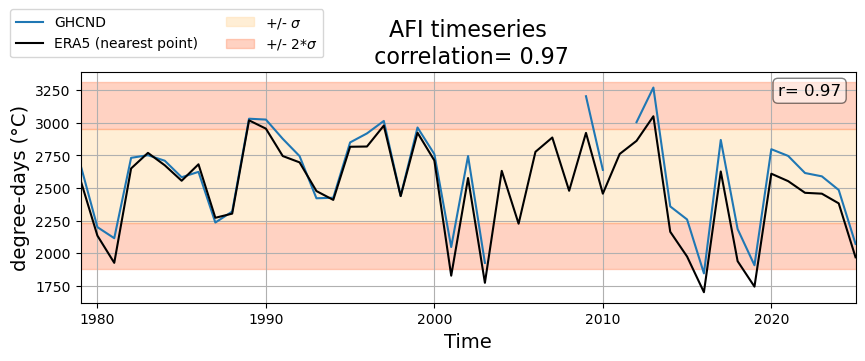

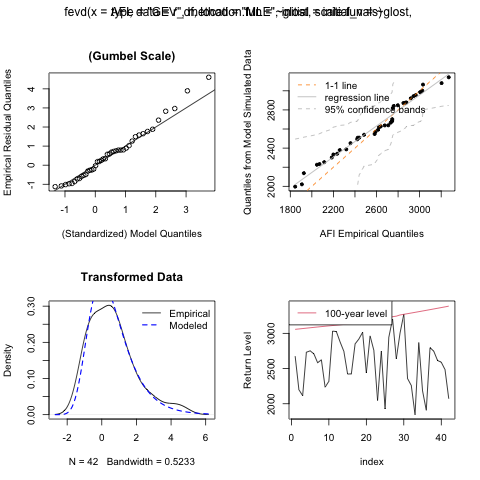

In [450]:

for ij in range(0,len(Tstations)):
  #for ij in range(2,3):
  ilon = longitude.sel(station = Tstations[ij]).data
  ilat = latitude.sel(station = Tstations[ij]).data
  # Extract values for boxes
  dsij = ds.sel(station = Tstations[ij])
  df = dsij.to_dataframe()
  df = df.reset_index()

  print('#########################################')  
  print(f'Processing station {dsij.name.data.item()} at lon={ilon}, lat={ilat}')
  print('#########################################')  

  x = dsij['time']
  y1 = dsij['AFI'].mean('time')-dsij['AFI'].std('time')
  y2 = dsij['AFI'].mean('time')+dsij['AFI'].std('time')
  y3 = dsij['AFI'].mean('time')-2*dsij['AFI'].std('time')
  y4 = dsij['AFI'].mean('time')+2*dsij['AFI'].std('time')
  fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,3))
  dsij['AFI'].plot(ax=ax, label='GHCND')
  if not dsae['AFI'].sel(lon=slice(ilon-radius, ilon+radius), lat=slice(ilat-radius, ilat+radius)).mean('time').isnull().all():
    valid_ERA5 = find_nearest_valid(dsae['AFI'], ilon, ilat, radius = radius)
    afi_era5 = valid_ERA5.to_xarray()['AFI']
  ax.plot(dsij['time'], afi_era5, color='k', ls='-', linewidth=1.5, label='ERA5 (nearest point)')  
  ax.fill_between(x, y1, y2, color='navajowhite', alpha=0.5,label='+/- $\sigma$')
  ax.fill_between(x, y2, y4, color='coral', alpha=0.35,label='+/- 2*$\sigma$')
  ax.fill_between(x, y1, y3, color='coral', alpha=0.35)
  ax.set_ylabel(f'{units}',fontsize=14)
  ax.set_xlabel('Time',fontsize=14)
  ax.grid()
  # set y axis lim
  ax.set_xlim(x.min(),x.max())
  # show legend
  ax.legend(loc='upper left',ncol=2,bbox_to_anchor=(-0.1,1.3),prop={'size': 10})
  ###
  mask = ~np.isnan(dsij['AFI'].values) & ~np.isnan(afi_era5.values)
  correlation = np.corrcoef(dsij['AFI'].values[mask], afi_era5.values[mask])[0, 1]
  ax.text(0.9, 0.95, f'r= {correlation:.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
  ###

  ax.set_title(f'AFI timeseries\n correlation= {correlation:.2f}',fontsize=16)
  plt.show()


  df = df.assign(cell=1)
  # Remove zeros and NAN 
  # Remove timeseries with less than 15 data (as in Bilotta et al.)
  # Save rows removed
  dfsave = df[(df['AFI'] <= 0.)|(df['AFI'].isna())]
  df = df[df['AFI'] > 0.]

  itime = df['time'].values
  ntime = len(itime)

  loc_init = df['AFI'].mean()
  scale_init = df['AFI'].std()
  shape_init = 0.01

  glost = ann_glost.sel(time=slice(yearb,yeare)).to_dataframe().reset_index()
  dftime = np.arange(yearb,yeare+1)
  %R -i ntime,loc_init,scale_init,shape_init,glost

  if df.empty == False: 
    # Convert xarray to pandas DataFrame to R data.frame
    # You can now work with 'r_df' in R

    with (ro.default_converter + pandas2ri.converter).context():
      r_df = ro.conversion.get_conversion().py2rpy(df)
    globalenv['r_df'] = r_df
    #%R names(r_df)[names(r_df) == "time"] <- "year"
    # Extremes GEV model fitting  
    %R initial_vals <- list(location = loc_init, scale = scale_init, shape = shape_init)
    %R call_fevd <- paste("fevd(AFI, data = r_df,",fevd_options,")")
    %R m_gev <- eval(parse(text = call_fevd))
    %R plot(m_gev,rp=c(100))
    %R m_gevL <- fevd(AFI, data = r_df,type='GEV',method='MLE', initial = initial_vals, location.fun= ~ glost)
    %R m_gevS <- fevd(AFI, data = r_df,type='GEV',method='MLE', initial = initial_vals )

    %R pp <- summary(m_gev, silent = TRUE)
    %R rpvalueL <- lr.test(m_gevS, m_gevL)$p.value
    %R rpvalueS <- lr.test(m_gevL, m_gev)$p.value
    %R -o rpvalueL,rpvalueS

    #%R loc <- findpars(m_gev)$location
    #%R sca <- findpars(m_gev)$scale
    #%R sha <- findpars(m_gev)$shape
    %R loc <- pp$par[['mu0']] + pp$par[['mu1']]*glost$GLOST
    %R sca <- pp$par[['sigma0']] + pp$par[['sigma1']]*glost$GLOST
    %R sha <- rep(pp$par[['shape']],times =length(glost$GLOST))
    %R rAIC <- pp$AIC
    %R rBIC <- pp$BIC
    %R -o loc,sca,sha,rAIC,rBIC

    if sca.all() > 0.:
        %R v <- make.qcov(m_gev,vals=list(mu1=glost$GLOST,sigma1=glost$GLOST))
        %R gev_rl <- return.level(m_gev, return.period = rp, qcov = v)
        %R -o gev_rl
        
        ######
        # Cross-Validation
        ######
        %R splits <- rep(c(1,2,3,4,5),times =ceiling(ntime/5))[1:ntime]
        #%R splits[as.integer(ntime-5):ntime] <- 0
        %R tests_scores <- cross_validation(r_df,fevd_options,K)
        %R ktime <- tests_scores$scores_cv$time
        %R df_ks_cvm <- tests_scores$tests
        %R SE <- tests_scores$scores_cv$SE
        %R DawSeb <- tests_scores$scores_cv$DawSeb
        %R CRPS <- tests_scores$scores_cv$CRPS      
        %R rAIC_cv <- tests_scores$AIC_cv
        %R rBIC_cv <- tests_scores$BIC_cv
        %R -o ktime,SE,DawSeb,CRPS,df_ks_cvm,rAIC_cv,rBIC_cv

        ######
        # Confidence Intervals
        ######
        if compute_CI == True:
          %R boot <- extremes_bootLS(r_df,fevd_options,300,0.1,rp)
          %R DLoc_qr <- boot$Dloc_q
          %R DScale_qr <- boot$Dsca_q
          %R DRL_qr <- boot$DRL_q
          %R Loc_qr <- boot$loc_q
          %R Scale_qr <- boot$sca_q
          %R RL_qr <- boot$RL_q
          %R -o DLoc_qr,DScale_qr,DRL_qr,Loc_qr,Scale_qr,RL_qr

        ######
        # Write output
        ######

        location.loc[{'time':dftime,'station':Tstations[ij]}] = loc
        scale.loc[{'time':dftime,'station':Tstations[ij]}] = sca
        shape.loc[{'time':dftime,'station':Tstations[ij]}] = sha
        for irp in range(0,len(return_periods)):
          rl.loc[{'time':dftime,'station':Tstations[ij],'return_periods':return_periods[irp]}] = gev_rl[:,irp]
        AIC.loc[{'station':Tstations[ij]}] = rAIC.item()
        BIC.loc[{'station':Tstations[ij]}] = rBIC.item()
        pvalueL.loc[{'station':Tstations[ij]}] = rpvalueL.item()
        pvalueS.loc[{'station':Tstations[ij]}] = rpvalueS.item()

        # CV
        SE_cv.loc[{'time':ktime,'station':Tstations[ij]}] = SE
        DawSeb_cv.loc[{'time':ktime,'station':Tstations[ij]}] = DawSeb
        CRPS_cv.loc[{'time':ktime,'station':Tstations[ij]}] = CRPS
        KS_D_cv.loc[{'time':ktime,'station':Tstations[ij]}] = df_ks_cvm['KS_D'].values
        KS_pvalue_cv.loc[{'time':ktime,'station':Tstations[ij]}] = df_ks_cvm['KS_pvalue'].values
        CVM_D_cv.loc[{'time':ktime,'station':Tstations[ij]}] = df_ks_cvm['CVM_D'].values
        CVM_pvalue_cv.loc[{'time':ktime,'station':Tstations[ij]}] = df_ks_cvm['CVM_pvalue'].values
        AIC_cv.loc[{'station':Tstations[ij]}] = rAIC_cv
        BIC_cv.loc[{'station':Tstations[ij]}] = rBIC_cv

        # CI
        itime = df['time'].values
        if compute_CI == True:
          Dlocation_q.loc[{'station':Tstations[ij]}] = DLoc_qr[0,:].T
          Dscale_q.loc[{'station':Tstations[ij]}] = DScale_qr[0,:].T
          location_q.loc[{'time':itime,'station':Tstations[ij]}] = Loc_qr.T
          scale_q.loc[{'time':itime,'station':Tstations[ij]}] = Scale_qr.T
          for irp in range(0,len(return_periods)):
            Drl_q.loc[{'station':Tstations[ij],'return_periods':return_periods[irp]}] = DRL_qr[irp,:]
            rl_q.loc[{'time':itime,'station':Tstations[ij],'return_periods':return_periods[irp]}] = RL_qr[:,:,irp]

**Figure caption (per station).** Top figure: Air-Freezing Index (AFI) time series for each GHCND station, with comparison to the ERA5 nearest-neighbor point. Shaded bands represent ±1σ and ±2σ variability around the mean. The correlation coefficient between GHCND and ERA5 AFI is displayed in the upper-right corner of each plot.
Bottom figure: Diagnostics from the GEV df fitted to the AFI data shown above. Quantile-quantile plot (top left) quantiles from a sample drawn from the fitted GEV df against the empirical data quantiles with 95% confidence bands (top right), density plots of empirical data and fitted GEV df (bottom left), and AFI are plotted as a line along with associated effective return levels for return periods of 100 years (bottom right).

In [440]:
dsout=rl.to_dataset(name='rl')
dsout=dsout.merge({'location':location,'scale':scale,'shape':shape})
dsout=dsout.merge({'AIC':AIC,'BIC':BIC,'pvalueL':pvalueL,'pvalueS':pvalueS})
#
if compute_CI == True:
  dsout=dsout.merge({'location_q':location_q})
  dsout=dsout.merge({'scale_q':scale_q})
  dsout=dsout.merge({'rl_q':rl_q})
  dsout=dsout.merge({'Difflocation_q':Dlocation_q})
  dsout=dsout.merge({'Diffscale_q':Dscale_q})
  dsout=dsout.merge({'Diffrl_q':Drl_q})
#
dsout=dsout.merge({'CRPS_cv':CRPS_cv})
dsout=dsout.merge({'DawSeb_cv':DawSeb_cv,'SE_cv':SE_cv})
dsout=dsout.merge({'KS_D_cv':KS_D_cv,'KS_pvalue_cv':KS_pvalue_cv,'CVM_D_cv':CVM_D_cv,'CVM_pvalue_cv':CVM_pvalue_cv})
dsout=dsout.merge({'AIC_cv':AIC_cv,'BIC_cv':BIC_cv})
#
dsout = dsout.merge({'elevation':ds.elevation,'name': ds.name,'state':ds.state,'GHCN_ID':ds.GHCN_ID,\
              'longitude':ds.longitude,'latitude':ds.latitude})
#


### Consolidate Results and Prepare NetCDF Output

Merge all fitted parameters, return levels, diagnostic metrics, cross-validation scores, and bootstrap-derived confidence intervals into a single xarray Dataset. Include station metadata (elevation, location, name, state, GHCN ID).

In [441]:
dsout = dsout.sel(station=Tstations)

### Save Results to NetCDF File

Filter the dataset to include only the successfully processed stations and write the complete results to a NetCDF file for downstream analysis and visualization.

In [442]:
dsout.to_netcdf(f'~/data/AFI/{itest}_{yearb}_{yeare}.nc')